Section 1 — Import Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings for a clean look
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
%matplotlib inline

Section 2 — Load Dataset

In [2]:
# Load the data
df = pd.read_csv('cleaned_superstore.csv') 
# Quick look at the data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November,2016
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November,2016
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June,2016
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October,2015
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October,2015


Section 3 — Data Cleaning

In [3]:
# 1. Convert Date columns to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 2. Check for missing values
print("Missing values:\n", df.isnull().sum())

# 3. Basic cleaning (Example: removing duplicates)
df.drop_duplicates(inplace=True)

# 4. Feature Engineering (Optional but professional)
df['Month'] = df['Order Date'].dt.month_name()
df['Year'] = df['Order Date'].dt.year

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Month            0
Year             0
dtype: int64


Section 4 — Data Analysis

In [4]:
# Answering key business questions
print("--- Most Valuable Segment ---")
print(df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False))

print("\n--- Region Performance ---")
print(df.groupby('Region')['Profit'].sum().sort_values())

--- Most Valuable Segment ---
                    Sales       Profit
Segment                               
Consumer     1.161401e+06  134119.2092
Corporate    7.061464e+05   91979.1340
Home Office  4.296531e+05   60298.6785

--- Region Performance ---
Region
Central     39706.3625
South       46749.4303
East        91522.7800
West       108418.4489
Name: Profit, dtype: float64


Section 5 — Visualizations


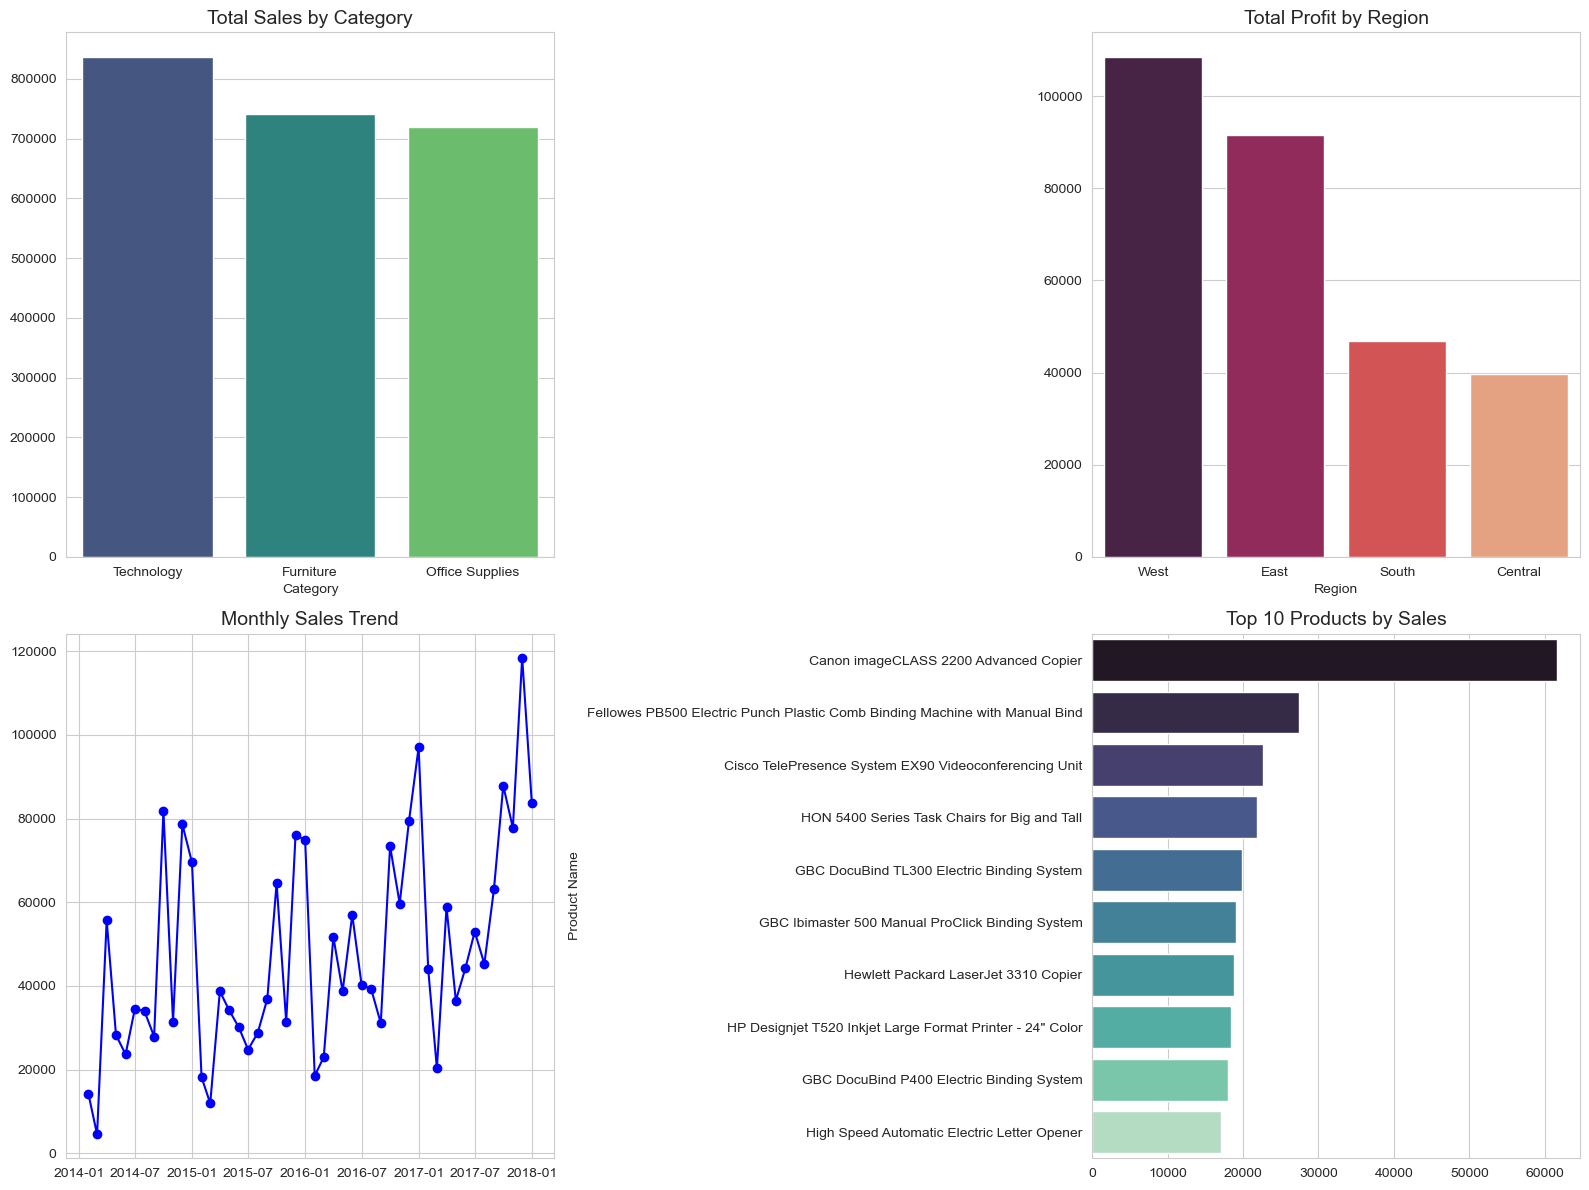

In [5]:
plt.figure(figsize=(16, 12))

# 1. Sales by Category
plt.subplot(2, 2, 1)
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, hue=category_sales.index, palette="viridis", legend=False)
plt.title('Total Sales by Category', fontsize=14)

# 2. Profit by Region
plt.subplot(2, 2, 2)
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=region_profit.index, y=region_profit.values, hue=region_profit.index, palette="rocket", legend=False)
plt.title('Total Profit by Region', fontsize=14)

# 3. Monthly Sales Trend (Using 'ME' to avoid deprecation warnings)
plt.subplot(2, 2, 3)
monthly_trend = df.resample('ME', on='Order Date')['Sales'].sum()
plt.plot(monthly_trend.index, monthly_trend.values, marker='o', color='b')
plt.title('Monthly Sales Trend', fontsize=14)

# 4. Top 10 Products
plt.subplot(2, 2, 4)
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette="mako", legend=False)
plt.title('Top 10 Products by Sales', fontsize=14)

plt.tight_layout()
plt.show()

### Section 6 — Final Insights

* **Top Revenue Driver:** The Technology category leads in total sales. However, further analysis of profit margins is recommended to ensure these high-value items aren't being offset by high shipping or discount costs.
* **Regional Performance:** The West region is the strongest performer in terms of profit. Conversely, the Central region shows significantly lower profit despite healthy sales, suggesting a need to review local discounting strategies or operational costs.
* **Growth Trends:** The Monthly Sales Trend indicates strong seasonality, with a consistent spike in revenue during the fourth quarter (October–December). This suggests that holiday promotions are a major driver of annual success.
* **Product Strategy:** A small number of "Hero Products" (like high-end Copiers and Phones) drive a disproportionate amount of total revenue. Maintaining high stock levels and premium service for these specific items is critical.
* **Customer Loyalty:** The Consumer segment remains the most valuable. Future marketing efforts should focus on retaining this base while exploring ways to increase the average order value in the Corporate segment.